#Assignment 2

Max collaborators = 3

Hand holding is low for this assignment. Adjust accordingly. In case of confusion, feel free to reach out to your lab faculties. Good luck.

In [1]:
COLLABORATORS_NAME = "Shuvashis Basak"
COLLABORATORS_ID = "22301769"

#Loading dependencies

In [2]:
import numpy as np
from tensorflow import keras
import sklearn
import matplotlib.pyplot as plt
#add if more dependencies are required here
from sklearn.preprocessing import StandardScaler

#Loading dataset

In [3]:
id = 2230169  #insert id of any one collaborator in int

(x_train, y_train), (x_test, y_test) = keras.datasets.cifar10.load_data()

x_train, y_train = sklearn.utils.resample(x_train, y_train, replace = False, n_samples = 5000, random_state = id, stratify = y_train)
x_test, y_test = sklearn.utils.resample(x_test, y_test, replace = False, n_samples = 1000, random_state = id, stratify = y_train)

170498071/170498071 ━━━━━━━━━━━━━━━━━━━━ 13s 0us/step


#Task 1: Training a logistic regressor [10 Marks]

###1. Convert the images to grayscale

In [4]:
def rgb_to_grayscale(images):
    """Converts RGB images to grayscale."""
    # Using the luminosity method
    return np.dot(images[..., :3], [0.2989, 0.5870, 0.1140])

x_train_gray = rgb_to_grayscale(x_train)
x_test_gray = rgb_to_grayscale(x_test)


### 2. Prepare the grayscale images for logistic regressor (reshape and normalize)

Use z-score normalization.

In [5]:
x_train_gray = x_train_gray.reshape((x_train_gray.shape[0], -1))
x_test_gray = x_test_gray.reshape((x_test_gray.shape[0], -1))

scaler = StandardScaler()
x_train_gray = scaler.fit_transform(x_train_gray)
x_test_gray = scaler.transform(x_test_gray)

###3. Create a validation set (20%)

In [7]:
from sklearn.model_selection import train_test_split

x_train_split, x_val_split, y_train_split, y_val_split = train_test_split(
    x_train_gray, y_train, test_size=0.2, random_state=id, stratify=y_train
)

###4. Compute class weights

Go through this link - https://scikit-learn.org/stable/modules/generated/sklearn.utils.class_weight.compute_class_weight.html

In [9]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train_split),
    y=y_train_split.ravel()
)
class_weight_dict = {i: w for i, w in enumerate(class_weights)}

###5. Run the logistic regressor

Use L2 regularizer. Find the C hyperparameter value through grid search. Pick the testing values according to your understanding. Use at least 3 test values and at max 5. Use the computed class weights while training your model.

In [11]:
param_grid = {"C": [0.1, 1, 10]}  # at least 3 test values

log_reg = LogisticRegression(
    multi_class="multinomial",
    solver="lbfgs",
    max_iter=500,
    class_weight=class_weight_dict
)

grid = GridSearchCV(log_reg, param_grid, cv=3, n_jobs=-1, verbose=1)
grid.fit(x_train_split, y_train_split.ravel())

print("Best C:", grid.best_params_)

Fitting 3 folds for each of 3 candidates, totalling 9 fits


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


Best C: {'C': 0.1}


###6. Evaluate the logistic regressor on the test set

In [12]:
score = grid.best_estimator_.score(x_test_gray, y_test.ravel())
print("Test Accuracy:", score)

Test Accuracy: 0.208


###7. Write code to pick up a random image from the test set and display it

In [14]:
idx = random.randint(0, len(x_test_gray)-1)
image = x_test[idx]
true_label = y_test[idx][0]


###8. Print the predicted class vs the original class

Do not print out the numerical class. Map it from here - https://keras.io/2/api/datasets/cifar10/

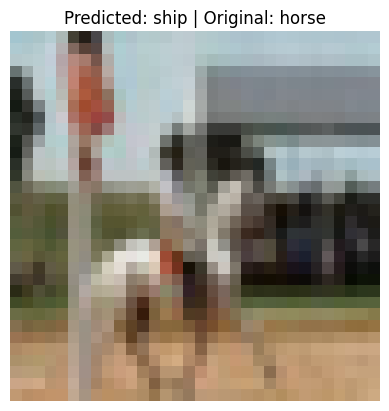

In [16]:
pred_label = grid.best_estimator_.predict(x_test_gray[idx].reshape(1, -1))[0]
plt.imshow(image)
plt.axis("off")
plt.title(f"Predicted: {cifar10_labels[pred_label]} | Original: {cifar10_labels[true_label]}")
plt.show()

#Task 2: Training a convolutional neural network [20 Marks]

We will not strictly control how you implement this code. You can use either Tensorflow or PyTorch. However the structure of the network must be -

```
Input -> Conv1 -> Conv2 -> Conv3 -> Fully Connected 1 -> Fully Connected 2 -> Output
```

Use activation functions and pooling as you want. Feel free to adjust dimensions as you need. Set the hyperparameters yourself. Use a maximum learning rate of 0.01 and a maximum epoch number of 100. Use AdamW as optimizer.

**Try achieving good accuracy. There are marks for that.**

###1. Train the model on grayscale images

You do not need to use the validation set. Train on the initial train set. Recalculate the class weights again and pass it to the optimizer function. Normalize the images before processing.

In [ ]:
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D, MaxPooling2D, Flatten, Dense
from tensorflow.keras.optimizers import AdamW
from sklearn.utils.class_weight import compute_class_weight

# Reshape grayscale images to have a channel dimension
x_train_gray_cnn = x_train_gray.reshape(-1, 32, 32, 1)
x_test_gray_cnn = x_test_gray.reshape(-1, 32, 32, 1)

# Normalize grayscale images (already done by StandardScaler, but adding for completeness if not using StandardScaler)
# x_train_gray_cnn = x_train_gray_cnn / 255.0
# x_test_gray_cnn = x_test_gray_cnn / 255.0

# Compute class weights for the full training set
class_weights_cnn = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_train),
    y=y_train.ravel()
)
class_weight_dict_cnn = {i: w for i, w in enumerate(class_weights_cnn)}


# Define the CNN model
model_gray = Sequential([
    Conv2D(32, (3, 3), activation='relu', input_shape=(32, 32, 1)),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    MaxPooling2D((2, 2)),
    Conv2D(64, (3, 3), activation='relu'),
    Flatten(),
    Dense(64, activation='relu'),
    Dense(10, activation='softmax')
])

# Compile the model
optimizer = AdamW(learning_rate=0.001) # Using a learning rate <= 0.01 as required
model_gray.compile(optimizer=optimizer,
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train the model
history_gray = model_gray.fit(x_train_gray_cnn, y_train, epochs=10, # Using a reasonable number of epochs <= 100
                              class_weight=class_weight_dict_cnn,
                              validation_split=0.0) # No validation split as per instructions

###2. Evaluate the model on the grayscale test set

###3. Write code to pick up a random image from the test set and display it

###4. Print the predicted class vs the original class

###5. Train the model on the RGB images

Keep the model same.

###6. Evaluate the model on the RGB images

###7. Write code to pick up a random image from the test set and display it

###8. Print the predicted class vs the original class

###9. Add one more conv layer and check if it increases the performance for the RGB images

###10. Use the next markup to write down your observations and reasonings on the performances of the models

Observations -

\*Delete this and write here\*